<a href="https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/Train_ALIGNNFF_Mlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Train machine learning force-field with [ALIGNN](https://github.com/atomgptlab/alignn) for example Silicon dataset

# Table of contents

1. Install [ALIGNN](https://github.com/usnistgov/alignn)
2. Train a simple Silicon ALIGNN-FF,
3. Post-raining analysis, equation of state
4. ALIGNN-FF Ase Calculator: predict energy/forces, optimized strcture, EV curves and phonons
5. Run example MD (Melt-quench) to make amorphous Silicon
6. Phonon bandstructure for silicon
7. Scaling with number of atoms
8. Add ALIGNN-results to the JARVIS-Leaderboard

Author: Kamal Choudhary (kamal.choudhary@nist.gov)

Install JARVIS-Leaderboard and ALIGNN

In [1]:
%%time
import os
# !pip install -q alignn
# !pip uninstall dgl -y
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html
!pip install -q -e .
# !uv pip install -q -e .
os.chdir('/content')

Cloning into 'alignn'...
remote: Enumerating objects: 5735, done.
remote: Counting objects: 100% (614/614), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 5735 (delta 565), reused 557 (delta 524), pack-reused 5121 (from 2)
Receiving objects: 100% (5735/5735), 155.35 MiB | 21.80 MiB/s, done.
Resolving deltas: 100% (3476/3476), done.
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
Switched to a new branch 'develop'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 231.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 276.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 207.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.

In [2]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

In [3]:
# !conda --version

In [4]:
# import condacolab
# condacolab.check()

In [5]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [6]:
# %%time
# Takes about 3 minutes to install packages
# !pip uninstall dgl -y
# !pip install -q git+https://github.com/usnistgov/jarvis.git@develop
# #!pip install  -q dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html # for cpu only
# !pip install  -q dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
# !pip install -q git+https://github.com/usnistgov/alignn.git@develop
# # Alternate
# # !conda install alignn dgl=2.1.0 pytorch torchvision torchaudio pytorch-cuda -c pytorch -c nvidia -y --quiet

Make sure torch cuda version is installed properly

In [7]:
import torch
torch.cuda.is_available()

True

In [8]:
%%time
import os
os.chdir('/content')

!rm -rf jarvis_leaderboard
# Clone JARVIS-Leaderboard repo to get example folder
if not os.path.exists('jarvis_leaderboard'):
  !git clone https://github.com/atomgptlab/jarvis_leaderboard.git
os.chdir('jarvis_leaderboard')
!pip install -q -e .
os.chdir('/content')

Cloning into 'jarvis_leaderboard'...
remote: Enumerating objects: 89613, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 89613 (delta 170), reused 151 (delta 151), pack-reused 89433 (from 2)
Receiving objects: 100% (89613/89613), 547.42 MiB | 22.45 MiB/s, done.
Resolving deltas: 100% (46540/46540), done.
Updating files: 100% (4695/4695), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textblob 0.19.0 requires nltk>=3.9, but you have nltk 3.8.1 which is incompatible.
CPU times: user 1.67 s, sys: 236 ms, total: 1.91 s
Wall time: 55.8 s


## Runtime>> Restart session

In [9]:
import alignn

In [10]:
import requests

url = "https://ndownloader.figshare.com/files/46761919"
r = requests.get(url, allow_redirects=True)
open("mlearn_si_id_prop.json.zip", "wb").write(r.content)


370467

In [11]:
!ls

alignn	jarvis_leaderboard  mlearn_si_id_prop.json.zip	sample_data


In [12]:
# !!wget https://figshare.com/ndownloader/files/46761919 -O mlearn_si_id_prop.json.zip


In [13]:
# !wget https://figshare.com/ndownloader/files/40357663 -O mlearn.json.zip

In [14]:
!pwd

/content


Lets look at default alignn-ff model config, Restart session

In [1]:
import numpy
numpy.__version__

'2.0.2'

In [2]:
from alignn.ff.ff import default_path, AlignnAtomwiseCalculator
path = default_path()
print(path)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
dir_path /root/.cache/atomgptlab/alignn_ff/v12.2.2024_dft_3d_307k


100%|██████████| 549k/549k [00:00<00:00, 5.82MiB/s]

/root/.cache/atomgptlab/alignn_ff/v12.2.2024_dft_3d_307k


In [3]:
# !ls /usr/local/lib/python3.11/site-packages/alignn/ff/v12.2.2024_dft_3d_307k

In [4]:
from jarvis.db.jsonutils import loadjson,dumpjson
import pprint
config=loadjson(path+'/config.json')
pprint.pprint(config)

{'atom_features': 'atomic_number',
 'batch_size': 6,
 'classification_threshold': None,
 'criterion': 'l1',
 'cutoff': 4.0,
 'cutoff_extra': 3.0,
 'data_parallel': False,
 'dataset': 'user_data',
 'distributed': False,
 'dtype': 'float32',
 'epochs': 300,
 'filename': 'sample',
 'id_tag': 'jid',
 'keep_data_order': True,
 'learning_rate': 0.001,
 'log_tensorboard': False,
 'max_neighbors': 12,
 'model': {'add_reverse_forces': True,
           'additional_output_features': 0,
           'additional_output_weight': 0.0,
           'alignn_layers': 2,
           'atom_input_features': 1,
           'atomwise_output_features': 0,
           'atomwise_weight': 0.0,
           'batch_stress': True,
           'calculate_gradient': True,
           'classification': False,
           'edge_input_features': 80,
           'embedding_features': 64,
           'energy_mult_natoms': True,
           'exponent': 5,
           'extra_features': 0,
           'force_mult_natoms': False,
           '

We are going to update n_train, n_val, n_test as per this dataset keeping evrything else fixed. These number are taken from jarvis-leaderboard


In [5]:
config['n_train']=214
config['n_val']=25
config['n_test']=25
config['epochs']=30

# config['compute_line_graph']=False
# config["model"]['alignn_layers']=0


dumpjson(data=config, filename='config_si_mlearn.json')



In [6]:
!unzip mlearn_si_id_prop.json.zip

Archive:  mlearn_si_id_prop.json.zip
  inflating: mlearn_si_id_prop.json  


In [7]:
import os
from jarvis.db.jsonutils import loadjson,dumpjson
!rm mlearn_si_id_prop.json
if not os.path.exists('DataDir'):
  os.makedirs('DataDir')
!unzip mlearn_si_id_prop.json.zip
!mv mlearn_si_id_prop.json DataDir/id_prop.json
# null=None
# true=True
# false=False
# my_config ={
#     "dataset": "user_data",
#     "target": "target",
#     "atom_features": "atomic_number",
#     "neighbor_strategy": "radius_graph",
#     "id_tag": "jid",
#     "random_seed": 123,
#     "classification_threshold": null,
#     "n_val": 25,
#     "n_test": 25,
#     "n_train": 214,
#     "epochs": 20,
#     "batch_size": 6,
#     "weight_decay": 1e-05,
#     "learning_rate": 0.001,
#     "filename": "sample",
#     "warmup_steps": 2000,
#     "criterion": "l1",
#     "optimizer": "adamw",
#     "scheduler": "onecycle",
#     "pin_memory": false,
#     "save_dataloader": false,
#     "write_checkpoint": true,
#     "write_predictions": true,
#     "store_outputs": false,
#     "progress": true,
#     "log_tensorboard": false,
#     "standard_scalar_and_pca": false,
#     "use_canonize": true,
#     "num_workers": 0,
#     "cutoff": 4.0,
#     "cutoff_extra": 3.0,
#     "max_neighbors": 12,
#     "keep_data_order": true,
#     "normalize_graph_level_loss": false,
#     "distributed": false,
#     "data_parallel": false,
#     "n_early_stopping": null,
#     "output_dir": "OutputDir",
#     "use_lmdb": true,
#     "model": {
#         "name": "alignn_atomwise",
#         "alignn_layers": 2,
#         "gcn_layers": 2,
#         "atom_input_features": 1,
#         "edge_input_features": 80,
#         "triplet_input_features": 40,
#         "embedding_features": 64,
#         "hidden_features": 64,
#         "output_features": 1,
#         "grad_multiplier": -1,
#         "calculate_gradient": true,
#         "atomwise_output_features": 0,
#         "graphwise_weight": 1.0,
#         "gradwise_weight": 1.0,
#         "stresswise_weight": 0.0,
#         "atomwise_weight": 0.0,
#         "link": "identity",
#         "zero_inflated": false,
#         "classification": false,
#         "force_mult_natoms": false,
#         "energy_mult_natoms": true,
#         "include_pos_deriv": false,
#         "use_cutoff_function": false,
#         "inner_cutoff": 3.0,
#         "stress_multiplier": 1.0,
#         "add_reverse_forces": true,
#         "lg_on_fly": true,
#         "batch_stress": true,
#         "multiply_cutoff": false,
#         "use_penalty": true,
#         "extra_features": 0,
#         "exponent": 5,
#         "penalty_factor": 0.1,
#         "penalty_threshold": 1.0
#     }


# }

# config_name = "config_Si.json"
# dumpjson(data=my_config, filename=config_name)

Archive:  mlearn_si_id_prop.json.zip
  inflating: mlearn_si_id_prop.json  


Check input data format

The DataDir/id_prop.json contains arrays of dictionaries. Each dictionary has keys such as 'id', 'atoms', 'forces', 'total_energy'.


An example to convert a vasprun.xml to id_prop.json is available [here](https://gist.github.com/knc6/5513b21f5fd83a7943509ffdf5c3608b).

In [8]:
!ls

alignn		       DataDir		   mlearn_si_id_prop.json.zip
config_si_mlearn.json  jarvis_leaderboard  sample_data


In [9]:
from jarvis.db.jsonutils import loadjson
import pprint

d=loadjson('DataDir/id_prop.json')
# pprint.pprint(d[0])

In [10]:
!rm -rf sampletrain_data  sampleval_data sampletest_data

In [11]:
import alignn
alignn.__file__

In [12]:
import torch
torch.__version__

'2.4.0+cu121'

In [13]:
# # Only if you are using GPU based training
# !pip uninstall dgl -y
# !pip install --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.2/cu121/repo.html

In [14]:

%%time
!train_alignn.py --root_dir DataDir/ --config config_si_mlearn.json --output_dir OutputDir

/content/alignn/alignn/train.py:58: SyntaxWarning: invalid escape sequence '\ '
  / \  | |   |_ _/ ___| \ | | \ | |
fatal: not a git repository (or any of the parent directories): .git
world_size 1
root_dir DataDir/
len dataset 264
train_stress False
Using LMDB dataset.
MAX val: -4.5603584190625
MIN val: -5.4253234771875
MAD: 0.2771504487888568
Baseline MAE: 0.2861611033805039
data range -4.56655198359375 -5.4253234771875
line_graph True
100% 214/214 [00:01<00:00, 151.37it/s]
data range -4.5603584190625 -5.3883693821875
line_graph True
100% 25/25 [00:00<00:00, 149.17it/s]
data range -4.5603584190625 -5.3883693821875
line_graph True
100% 25/25 [00:00<00:00, 152.63it/s]
n_train: 214
n_val  : 25
n_test : 25
rank 0
world_size 1
config: {'version': 'af3ae5d1c5711ef9cad6cf930de78f30e6627382', 'dataset': 'user_data', 'target': 'target', 'atom_features': 'atomic_number', 'neighbor_strategy': 'radius_graph', 'id_tag': 'jid', 'dtype': 'float32', 'random_seed': 123, 'classification_threshold': No

In [15]:
!ls OutputDir

best_model.pt	    ids_train_val_test.json	 sampleval_data_data_range
config.json	    last_model.pt		 Test_results.json
current_model.pt    mad				 Train_results.json
history_train.json  sampletest_data_data_range	 Val_results.json
history_val.json    sampletrain_data_data_range


In [16]:
# Example of loading pytorch model, not necessary if you are going to use ASE calculator later
from alignn.models.alignn_atomwise import ALIGNNAtomWise , ALIGNNAtomWiseConfig
import torch
from jarvis.db.jsonutils import loadjson
config=loadjson('OutputDir/config.json')
restart_model_path = 'OutputDir/best_model.pt'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config['model']['stresswise_weight'] = 0.01 #to enable stress calculation
tmp = ALIGNNAtomWiseConfig(**config["model"])
model = ALIGNNAtomWise(tmp)
model.load_state_dict(torch.load(restart_model_path, map_location=device))
model = model.to(device)

/tmp/ipykernel_13269/1996622998.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(restart_model_path, map_location=device))


In [17]:
# !wget https://figshare.com/ndownloader/files/40357663 -O mlearn.json.zip

In [18]:
from jarvis.core.atoms import Atoms
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
from alignn.graphs import Graph
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from alignn.graphs import radius_graph_jarvis
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
calc = AlignnAtomwiseCalculator(path='OutputDir',device=device, force_mult_batchsize=False)


def get_pred(atoms=None):
    atoms=atoms.ase_converter()
    atoms.calc=calc
    return atoms.get_potential_energy(),atoms.get_forces(),atoms.get_stress()

    # # g,lg=radius_graph_jarvis(atoms=atoms,cutoff=config['cutoff'])
    # g,lg=Graph.atom_dgl_multigraph(atoms=atoms,cutoff=config['cutoff'])
    # out = model([g.to(device),lg.to(device)])
    # #print('out',out,out.keys())
    # energy = out['out'].cpu().detach().numpy()*atoms.num_atoms
    # forces = out['grad'].cpu().detach().numpy()*atoms.num_atoms
    # stress = np.zeros((3,3)) #out["stresses"][:3].reshape(3, 3).detach().cpu().numpy()
    # return energy,forces,stress






df = pd.DataFrame(
    json.loads(
        zipfile.ZipFile("mlearn_si_id_prop.json.zip").read(
            "mlearn_si_id_prop.json"
        )
    )
)
print(df)
element="Si"
# print(df)
for i in glob.glob("/content/jarvis_leaderboard/jarvis_leaderboard/benchmarks/AI/MLFF/*energy*.zip"):
    if "mlearn" in i and element in i:
        fname_e = (
            "AI-MLFF-energy-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-mae.csv"
        )
        fname_f = (
            "AI-MLFF-forces-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-multimae.csv"
        )
        fname_s = (
            "AI-MLFF-stresses-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-multimae.csv"
        )
        f_e = open(fname_e, "w")
        f_f = open(fname_f, "w")
        f_s = open(fname_s, "w")

        f_e.write("id,target,prediction\n")
        f_f.write("id,target,prediction\n")
        f_s.write("id,target,prediction\n")
        #voigt_6_to_full_3x3_stress
        print(i)
        dat = json.loads(
            zipfile.ZipFile(i).read(i.split("/")[-1].split(".zip")[0])
        )
        print(dat["test"])
        for key, val in dat["test"].items():
            entry = df[df["jid"] == key]
            atoms = Atoms.from_dict(entry.atoms.values[0])
            # print(key,val,df[df['jid']==key],atoms)
            # energy,forces=get_alignn_forces(atoms)
            energy, forces, stress = get_pred(atoms=atoms)
            # print(key, val, energy, atoms.num_atoms)
            line = key + "," + str(entry.total_energy.values[0]*atoms.num_atoms)+","+str(energy) + "\n"
            print(line)
            f_e.write(line)
            line = (
                key
                + ","
                + str(";".join(map(str, np.array(entry.forces.values[0]).flatten())))
                +","
                + str(";".join(map(str, np.array(forces).flatten())))
                + "\n"
            )
            f_f.write(line)
            line = (
                key
                + ","
                + str(";".join(map(str, np.array(voigt_6_to_full_3x3_stress(entry.stresses.values[0])).flatten())))
                +","
                + str(";".join(map(str, np.array(voigt_6_to_full_3x3_stress(stress)).flatten())))
                + "\n"
            )
            f_s.write(line)
        f_e.close()
        f_f.close()
        f_s.close()
        zname = fname_e + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_e)

        zname = fname_f + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_f)

        zname = fname_s + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_s)




        jid                                              atoms  total_energy  \
0      Si-1  {'lattice_mat': [[14.22366, 5.591921, 15.55731...     -4.690437   
1      Si-2  {'lattice_mat': [[14.390374, 2.309401, 14.7893...     -4.706461   
2      Si-3  {'lattice_mat': [[13.125139, 0.474114, 0.15710...     -4.779050   
3      Si-4  {'lattice_mat': [[14.457355, -2.049613, 13.272...     -4.668139   
4      Si-5  {'lattice_mat': [[14.727256, 2.798612, 5.54958...     -4.719795   
..      ...                                                ...           ...   
259  Si-235  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.386575   
260  Si-236  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.386575   
261  Si-237  {'lattice_mat': [[10.937456, 0.0, 0.0], [-1.31...     -5.331588   
262  Si-238  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.331588   
263  Si-239  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.331588   

                                       

/content/alignn/alignn/ff/calculators.py:319: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  torch.tensor(atoms.cell)


Si-215,-297.62773938,-294.73975

Si-216,-295.77170067,-293.30017

Si-217,-291.28958206,-291.20645

Si-218,-296.24088456,-292.88937

Si-219,-294.41361742,-291.37897

Si-220,-334.75283939,-336.8881

Si-221,-334.69215136,-337.12564

Si-222,-184.71808052,-188.91106

Si-223,-121.41180043,-124.12984

Si-224,-338.93899696,-337.96402

Si-225,-338.83557056,-337.90994

Si-226,-335.68901422,-334.5286

Si-227,-333.7064957,-332.1384

Si-228,-344.85564046,-344.02414

Si-229,-344.81108268,-344.01117

Si-230,-298.83222646,-297.85602

Si-231,-298.96501782,-298.35846

Si-232,-295.20943762,-294.45392

Si-233,-291.86293882,-291.08838

Si-234,-344.74080048,-342.0769

Si-235,-344.74080047,-342.0769

Si-236,-344.74080046,-342.0769

Si-237,-341.22165747,-340.8718

Si-238,-341.22165734,-340.87177

Si-239,-341.22165747,-340.8718



1.6689302952000002


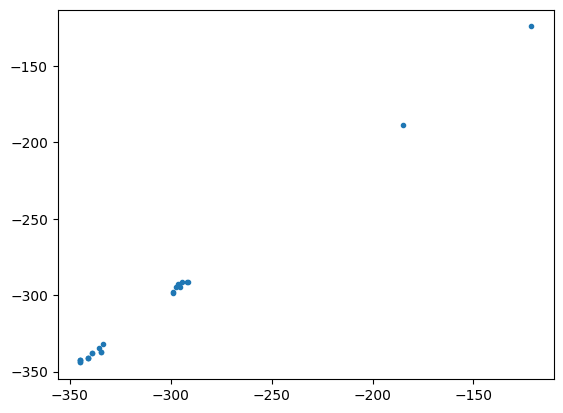

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
%matplotlib inline
df = pd.read_csv('AI-MLFF-energy-mlearn_Si-test-mae.csv')
plt.plot(df.target,df.prediction,'.')
print(mean_absolute_error(df.target,df.prediction))

0.10204289226835574


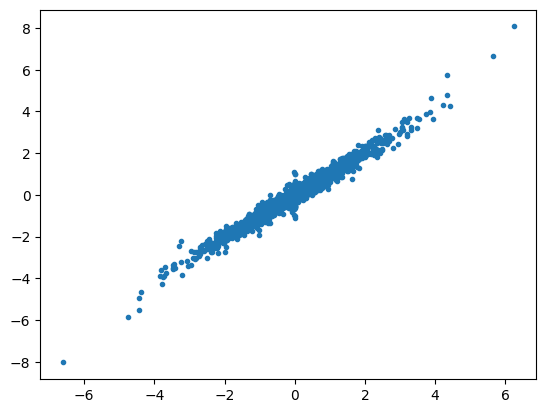

In [20]:
df = pd.read_csv('AI-MLFF-forces-mlearn_Si-test-multimae.csv.zip')
target = np.concatenate(df.target.apply(lambda x:np.array(x.split(';'),dtype='float')).values)
pred= np.concatenate(df.prediction.apply(lambda x:np.array(x.split(';'),dtype='float')).values)
print(mean_absolute_error(target,pred))
plt.plot(target,pred,'.')


In [21]:
# from ase.stress import voigt_6_to_full_3x3_stress

# df = pd.read_csv('AI-MLFF-stresses-mlearn_Si-test-multimae.csv.zip')
# target = np.concatenate(df.target.apply(lambda x:(np.array(x.split(';'),dtype='float')))).flatten()
# pred = 160*3*np.concatenate(df.prediction.apply(lambda x:(np.array(x.split(';'),dtype='float')))).flatten()
# print(mean_absolute_error(target,pred))
# plt.plot(target,pred,'.')


<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_13269/304991761.py:24: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Volume ($\AA^3$)')


Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 40.8M/40.8M [00:00<00:00, 74.0MiB/s]


Loading the zipfile...
Loading completed.
442.0646607213543


Text(0, 0.5, 'Total energy (eV)')

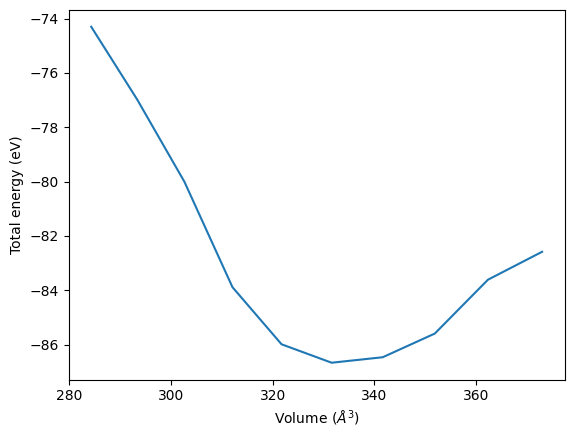

In [22]:
from ase.eos import EquationOfState
from ase.units import kJ
from jarvis.db.figshare import get_jid_data
from jarvis.core.atoms import Atoms
import matplotlib.pyplot as plt
%matplotlib inline
atoms=Atoms.from_dict(get_jid_data(jid='JVASP-1002',dataset='dft_3d')['atoms']).make_supercell([2,2,2])# get_conventional_atoms
#dx=np.arange(-0.1, 0.1, 0.01)
dx=np.arange(-0.05, 0.05, 0.01)
y = []
vol = []
for i in dx:
    s1 = atoms.strain_atoms(i)
    energy, forces, stress = get_pred(atoms=s1)
    y.append(energy)
    vol.append(s1.volume)
x = np.array(dx)
y = np.array(y)
eos = EquationOfState(vol, y, eos="murnaghan")
v0, e0, B = eos.fit()
kv = B / kJ * 1.0e24  # , 'GPa')
print(kv)
plt.plot(vol,y)
plt.xlabel('Volume ($\AA^3$)')
plt.ylabel('Total energy (eV)')


In [23]:
from jarvis.io.vasp.inputs import Poscar
from ase.filters import ExpCellFilter
from ase.optimize.fire import FIRE
from jarvis.core.atoms import ase_to_atoms
from ase.filters import FrechetCellFilter

poscar="""System
1.0
5.0 0.0 0.0
-0.0 5.0 0.0
0.0 0.0 5.0
Si
8
direct
0.25 0.75 0.25 Si
0.0 0.0 0.5 Si
0.25 0.25 0.75 Si
0.0 0.5 0.0 Si
0.75 0.75 0.75 Si
0.5 0.0 0.0 Si
0.75 0.25 0.25 Si
0.5 0.5 0.5 Si
"""
# 5.49363
atoms=Poscar.from_string(poscar).atoms


def general_relaxer(atoms="", calculator="", fmax=0.05, steps=150,relax=True):
    ase_atoms = atoms.ase_converter()
    ase_atoms.calc = calculator
    if not relax:
         return ase_atoms.get_potential_energy()
    #ase_atoms = ExpCellFilter(ase_atoms)
    ase_atoms = FrechetCellFilter(ase_atoms)
    dyn = FIRE(ase_atoms)
    dyn.run(fmax=fmax, steps=steps)
    return ase_to_atoms(ase_atoms.atoms)
opt = general_relaxer(atoms=atoms,calculator=calc)
print(opt)


      Step     Time          Energy          fmax
FIRE:    0 20:57:02      -38.139450        0.221922
FIRE:    1 20:57:03      -38.168972        0.221624
FIRE:    2 20:57:04      -38.227871        0.220987
FIRE:    3 20:57:04      -38.315777        0.219936
FIRE:    4 20:57:05      -38.432087        0.218361
FIRE:    5 20:57:05      -38.575855        0.216133
FIRE:    6 20:57:05      -38.745728        0.213116
FIRE:    7 20:57:05      -38.939857        0.209183
FIRE:    8 20:57:06      -39.179985        0.203655
FIRE:    9 20:57:06      -39.471497        0.196060
FIRE:   10 20:57:06      -39.817791        0.185977
FIRE:   11 20:57:06      -40.218815        0.173202
FIRE:   12 20:57:07      -40.669918        0.157905
FIRE:   13 20:57:07      -41.161343        0.140555
FIRE:   14 20:57:07      -41.677677        0.121426
FIRE:   15 20:57:07      -42.195011        0.100027
FIRE:   16 20:57:08      -42.675510        0.075547
FIRE:   17 20:57:08      -43.066700        0.048396
System
1.0
5.3

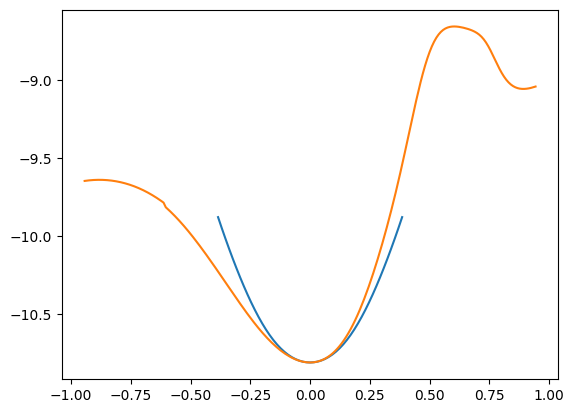

In [24]:
#Check translationally equivariant
from ase import Atom, Atoms
import numpy as np
import matplotlib.pyplot as plt


A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)

atoms_si.set_tags(np.ones(len(atoms_si)))
atoms_si.calc = calc

atoms_si.set_scaled_positions(np.array([[0,0,0],[0.25, 0.25, 0.25]]))

#"""
en = []
dist = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,0,0],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en.append(e)
    dist.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,0,0])**2)))
en_111_more = []
dist_111_more = []
for a in np.linspace(-0.1,  0.1, 201):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en_111_more.append(e)
    dist_111_more.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,a,a])**2)))
plt.plot(dist,en)
plt.plot(dist_111_more,en_111_more)
#plt.ylim([-10.7,-10])
# plt.savefig('inv.png')
# plt.close()
#"""




Melt quench

In [25]:
%%time
import ase,os
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.nvtberendsen import NVTBerendsen
from jarvis.db.figshare import get_jid_data
from jarvis.core.atoms import Atoms, ase_to_atoms
calc = AlignnAtomwiseCalculator(path='OutputDir',device=device, force_mult_batchsize=False)
!rm */*.traj
def ensure_cell_size(ase_atoms, min_size):
    """Ensure that all cell dimensions are at least min_size."""
    cell_lengths = ase_atoms.get_cell().lengths()
    scale_factors = np.ceil(min_size / cell_lengths).astype(int)
    supercell_dims = [max(1, scale) for scale in scale_factors]
    return supercell_dims

calculator = calc
jid = 'JVASP-1002'
atoms=Atoms.from_dict(get_jid_data(jid=jid,dataset='dft_3d')['atoms']).get_conventional_atoms
relaxed_atoms=atoms
ase_atoms = atoms.ase_converter()
dim = ensure_cell_size(ase_atoms, min_size=10.0)
supercell = relaxed_atoms.make_supercell_matrix(dim)
ase_atoms = supercell.ase_converter()
ase_atoms.calc = calculator

dt = 1 * ase.units.fs
temp0, nsteps0 = 3500, 1000
temp1, nsteps1 = 300, 2000
taut = 20 * ase.units.fs
if not os.path.exists("output_melt"):
    os.mkdir("output_melt")
trj = os.path.join("output_melt", f"{jid}_melt.traj")

# Initialize velocities and run the first part of the MD simulation


MaxwellBoltzmannDistribution(ase_atoms, temp0 * ase.units.kB)
dyn = NVTBerendsen(ase_atoms, dt, temp0, taut=taut, trajectory=trj)

def myprint():
    message = f"time={dyn.get_time() / ase.units.fs: 5.0f} fs T={ase_atoms.get_temperature(): 3.0f} K"
    print(message)
dyn.attach(myprint, interval=20)
dyn.run(nsteps0)

# Cool down to room temperature
dyn.set_temperature(temp1)
dyn.run(nsteps1)

# Convert back to JARVIS atoms and save the final structure
final_atoms = ase_to_atoms(ase_atoms)
poscar_filename = os.path.join(
    "output_melt", f"POSCAR_{jid}_quenched_{'alignn'}.vasp"
)
from ase.io import write

write(poscar_filename, final_atoms.ase_converter(), format="vasp")
# self.log(f"MD simulation completed. Final structure saved to {poscar_filename}")
# self.job_info["quenched_atoms"] = final_atoms.to_dict()


rm: cannot remove '*/*.traj': No such file or directory
Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


/usr/local/lib/python3.12/dist-packages/ase/md/md.py:54: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


time=    0 fs T= 3765 K
time=   20 fs T= 1963 K
time=   40 fs T= 2674 K
time=   60 fs T= 2442 K
time=   80 fs T= 2905 K
time=  100 fs T= 2740 K
time=  120 fs T= 3363 K
time=  140 fs T= 3095 K
time=  160 fs T= 3287 K
time=  180 fs T= 3161 K
time=  200 fs T= 3581 K
time=  220 fs T= 3341 K
time=  240 fs T= 3325 K
time=  260 fs T= 3690 K
time=  280 fs T= 3553 K
time=  300 fs T= 3549 K
time=  320 fs T= 3482 K
time=  340 fs T= 3336 K
time=  360 fs T= 3542 K
time=  380 fs T= 3428 K
time=  400 fs T= 3517 K
time=  420 fs T= 3391 K
time=  440 fs T= 3489 K
time=  460 fs T= 3670 K
time=  480 fs T= 3230 K
time=  500 fs T= 3672 K
time=  520 fs T= 3339 K
time=  540 fs T= 3455 K
time=  560 fs T= 3516 K
time=  580 fs T= 3349 K
time=  600 fs T= 3696 K
time=  620 fs T= 3593 K
time=  640 fs T= 3688 K
time=  660 fs T= 3340 K
time=  680 fs T= 3557 K
time=  700 fs T= 3358 K
time=  720 fs T= 3579 K
time=  740 fs T= 3599 K
time=  760 fs T= 3650 K
time=  780 fs T= 3355 K
time=  800 fs T= 3344 K
time=  820 fs T=

/tmp/ipykernel_13269/2636870775.py:38: FutureWarning: Use `ase.geometry.rdf.get_rdf` instead.
  distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]


System
1.0
10.98726 0.0 0.0
0.0 10.98726 0.0
0.0 0.0 10.98726
Si 
64 
direct
0.4611416421419783 0.6674572100200714 -0.47116895403018044 Si
0.35326949027749227 0.36605143678226154 0.7089026925865303 Si
-0.09389612252805299 0.7423483985213172 0.13030126739548398 Si
0.536201994137369 1.2896742568267063 0.6283647213577701 Si
0.11653808958841808 -0.05309418895586536 -0.02925610586348817 Si
0.8290537218344313 0.7524550787178379 0.46706179684731686 Si
0.684559931116128 0.9976401504095923 -0.2871070143427391 Si
0.9967805939348854 0.8930817634645892 0.7843860050078943 Si
0.21357245659753574 -0.1117978562788636 0.5427189941138605 Si
0.05769937116852533 0.5613051208204465 1.6288933444903722 Si
-0.5247042314167834 0.2005131537356613 0.29502700111164754 Si
0.29538480742235756 0.6936652917763297 0.862879440863882 Si
0.34553104577950694 -0.4976446457686568 0.4331626854396179 Si
-0.1284184471152012 0.30308896643816224 0.4740815928865061 Si
0.6129249703570466 0.7154821218615154 -0.10644204938569625 Si


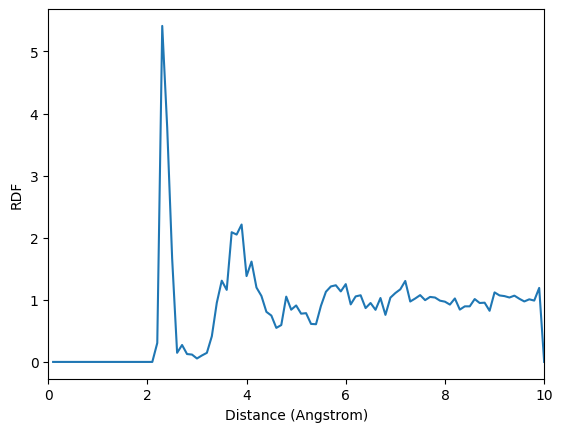

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from jarvis.core.atoms import Atoms
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
from ase.visualize.plot import plot_atoms
from matplotlib.animation import FuncAnimation
from ase.geometry.analysis import Analysis


traj = Trajectory('output_melt/JVASP-1002_melt.traj')


fig, ax = plt.subplots(1, 3, figsize=(9,3), tight_layout=True)

t = np.arange(nsteps0+nsteps1+1) * dt
temp = [atoms.get_temperature() for atoms in traj]

nframes = 20



def update(iframe):
    idx = int((nsteps0+nsteps1)*iframe/nframes)

    ax[0].clear()
    ax[0].set_title('Temperature')
    ax[0].set_xlabel('time (fs)')
    ax[0].set_ylabel('T (K)')
    ax[0].plot(t, temp)
    ax[0].plot(t[idx], temp[idx], marker='X', markersize=10)

    ax[1].clear()
    ax[1].set_title('Structure')
    ax[1].axis('off')
    plot_atoms(traj[idx], ax=ax[1], rotation='45x,45y')

    distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]
    ax[2].clear()
    ax[2].set_title('RDF')
    ax[2].set_ylim((0,10))
    ax[2].set_xlabel('distance (A))')
    ax[2].set_ylabel('distribution')
    ax[2].plot(distance, distribution, color='darkblue')
ani = FuncAnimation(fig, update, np.arange(nframes), blit=False, interval=250.)
ani.save('ani_si_2k.gif', writer="imagemagick")
plt.close()

atoms=ase_to_atoms(traj[-1])
print(atoms)
dists=[]
for i in atoms.get_all_neighbors(r=10):
    for j in i:
      dists.append(j[2])
dists=np.array(dists)
hist, bins = np.histogram(dists, bins=np.arange(0.1, 10.2, 0.1))
number_density = atoms.num_atoms / atoms.volume
shell_vol = (
            4.0
            / 3.0
            * np.pi
            * (np.power(bins[1:], 3) - np.power(bins[:-1], 3))
        )
rdf = (
            hist / shell_vol / number_density / atoms.num_atoms
        )
plt.plot(bins[:-1], rdf)
plt.xlim([0,10])
plt.xlabel('Distance (Angstrom)')
plt.ylabel('RDF')
# plt.savefig('rdf.png')
# plt.close()
plt.show()


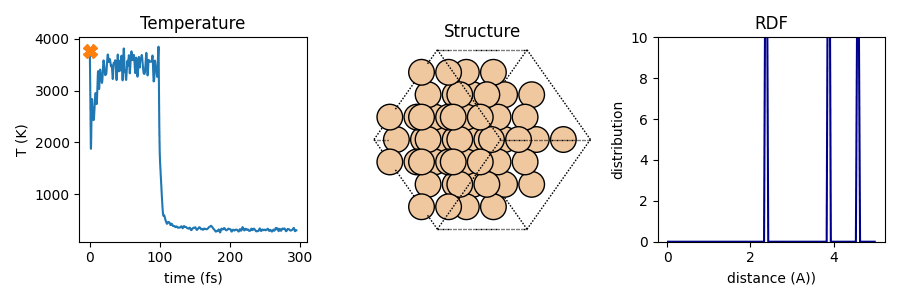

In [27]:
from IPython.display import Image, display

display(Image(filename='ani_si_2k.gif'))


In [28]:
from ase.visualize import view
view(atoms.ase_converter(),viewer='x3d')

In [ ]:
atoms.plot_atoms()


Scaling

In [ ]:
from ase.build.supercells import make_supercell
import numpy as np
import time
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from ase import Atoms,Atom
A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
model_path = "OutputDir"
dir_name = model_path
calc = AlignnAtomwiseCalculator(
    path=model_path,
    force_mult_natoms=False,
    stress_wt=0.3,
    device='cuda'
)
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
en = atoms_si.get_potential_energy()
numbers = np.arange(1,10,1)
times = []
natoms=[]
for i in numbers:

  sc=make_supercell(atoms_si, [[i,0,0],[0,i,0],[0,0,i]])
  t1=time.time()
  sc.calc = calc

  en = sc.get_potential_energy()/len(sc)
  t2=time.time()

  times.append(t2-t1)
  natoms.append(len(sc))
  print(i,len(sc),en,t2-t1)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(natoms,times,'o-')
plt.xlabel('Number of atoms')
plt.ylabel('Time (s)')
plt.show()

Training analysis

In [ ]:
from jarvis.db.jsonutils import loadjson
from matplotlib.gridspec import GridSpec
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import os
%matplotlib inline
# Plot training hostory for validation set
dir_name = "OutputDir"
json_path = os.path.join(dir_name, "history_val.json")
v = loadjson(json_path)
ens = []
fs = []
for i in v:
    ens.append(i[0])
    fs.append(i[1])
the_grid = GridSpec(1, 2)
plt.rcParams.update({"font.size": 18})
plt.figure(figsize=(12, 5))
plt.subplot(the_grid[0])
plt.title("(a) Energy")
plt.plot(ens)
plt.xlabel("Epochs")
plt.ylabel("eV")
plt.subplot(the_grid[1])
plt.title("(b) Forces")
plt.plot(fs)
plt.xlabel("Epochs")
plt.ylabel("eV/A")
plt.tight_layout()
plt.show()
# plt.savefig("history.png")
# plt.close()
print(v[-1])

In [ ]:
the_grid = GridSpec(1, 2)
json_path = os.path.join(dir_name, "Val_results.json")
test = loadjson(json_path)
plt.rcParams.update({"font.size": 18})
plt.figure(figsize=(12, 5))
plt.subplot(the_grid[0])
xx = []
yy = []
factor = 1
for i in test:
    for j, k in zip(i["target_out"], i["pred_out"]):
        xx.append(j)
        yy.append(k)
xx = np.array(xx) * factor
yy = np.array(yy) * factor

x_bar = np.mean(xx)
baseline_mae = mean_absolute_error(
    np.array(xx),
    np.array([x_bar for i in range(len(xx))]),
)
print("Val")
print("Baseline MAE: eV", baseline_mae)
print("MAE eV", mean_absolute_error(xx, yy))

plt.plot(xx, yy, ".")
plt.ylabel("ALIGNN Energy (eV)")
plt.xlabel("DFT Energy (eV)")
plt.subplot(the_grid[1])
xx = []
yy = []
for i in test:
    for j, k in zip(i["target_grad"], i["pred_grad"]):
        for m, n in zip(j, k):
            xx.append(m)
            yy.append(n)
xx = np.array(xx) * factor
yy = np.array(yy) * factor

x_bar = np.mean(xx)
baseline_mae = mean_absolute_error(
    np.array(xx),
    np.array([x_bar for i in range(len(xx))]),
)
print("Test")
print("Baseline MAE: eV/A", baseline_mae)
print("MAE eV/A", mean_absolute_error(xx, yy))
plt.scatter(xx, yy, c="blueviolet", s=10, alpha=0.5)

plt.scatter(xx, yy, c="blueviolet", s=10, alpha=0.5)
plt.ylabel("ALIGNN Force (eV/A)")
plt.xlabel("DFT Force (eV/A)")
plt.tight_layout()
plt.show()
# plt.savefig("val.png")
# plt.close()


Equation of state

## Phonon bandstructure

In [ ]:
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
from alignn.ff.ff import phonons
from jarvis.core.atoms import ase_to_atoms
from jarvis.core.atoms import Atoms
from jarvis.db.figshare import get_jid_data
import torch
torch.cuda.is_available = lambda: False
dir_name="OutputDir"
ph_path=dir_name
atoms=Atoms.from_dict(get_jid_data(jid='JVASP-1002',dataset='dft_3d')['atoms'])
ph=phonons(model_path=ph_path,atoms=atoms)
%matplotlib inline
plt.axis('off')
plt.imshow(plt.imread("phonopy_bands.png"))
plt.show()

You can compare the bandstructure here: https://www.ctcms.nist.gov/~knc6/static/JARVIS-DFT/JVASP-1002.xml#elastic_tensor

In [ ]:
tmp_ph=ph
ph.run_mesh(mesh=[20, 20, 20])
ph.run_thermal_properties(t_step=10, t_max=1000, t_min=0)
tprop_dict = ph.get_thermal_properties_dict()
plt.plot(tprop_dict['temperatures'],tprop_dict['free_energy'],label='Free energy',color='red')
plt.plot(tprop_dict['temperatures'],tprop_dict['entropy'],label='entropy',color='blue')
plt.plot(tprop_dict['temperatures'],tprop_dict['heat_capacity'],label='heat_capacity',color='green')
plt.legend()
print(tprop_dict.keys())

# See https://phonopy.github.io/phonopy/examples.html

Elastic constants

In [ ]:
!pip install -q elastic

In [ ]:
from elastic import get_elementary_deformations, get_elastic_tensor
import elastic
import ase
from jarvis.core.atoms import ase_to_atoms
from jarvis.core.atoms import Atoms
from jarvis.db.figshare import get_jid_data

ph_path=dir_name
atoms=Atoms.from_dict(get_jid_data(jid='JVASP-1002',dataset='dft_3d')['atoms']).get_conventional_atoms
ase_atoms = atoms.ase_converter()
ase_atoms.calc = calc
systems = get_elementary_deformations(ase_atoms)
cij_order = elastic.elastic.get_cij_order(ase_atoms)
Cij, Bij = get_elastic_tensor(ase_atoms, systems)
for i, j in zip(cij_order, Cij):
    print(i, j / ase.units.GPa)

In [ ]:
#Check translationally equivariant
from ase import Atom, Atoms
import numpy as np
import matplotlib.pyplot as plt


A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)

atoms_si.set_tags(np.ones(len(atoms_si)))
atoms_si.calc = calc

atoms_si.set_scaled_positions(np.array([[0,0,0],[0.25, 0.25, 0.25]]))

#"""
en = []
dist = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,0,0],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en.append(e)
    dist.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,0,0])**2)))
en_111_more = []
dist_111_more = []
for a in np.linspace(-0.1,  0.1, 201):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en_111_more.append(e)
    dist_111_more.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,a,a])**2)))
plt.plot(dist,en)
plt.plot(dist_111_more,en_111_more)
#plt.ylim([-10.7,-10])
# plt.savefig('kevin.png')
# plt.close()
#"""




In [ ]:
#Check rotationally equivariant
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
#translations
en_trans = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[a+0.25, a+0.25, a+0.25]]))
    e = atoms_si.get_potential_energy()
    en_trans.append(e)
plt.plot(en_trans)

Interface design, gamma surface plot

In [ ]:
!pip install -q git+https://github.com/usnistgov/intermat.git@develop

In [ ]:
# Conventional cells
poscar_1= """JVASP1002
1.0
5.49363 0.0 0.0
-0.0 5.49363 0.0
0.0 0.0 5.49363
Si
8
direct
0.25 0.75 0.25 Si
0.0 0.0 0.5 Si
0.25 0.25 0.75 Si
0.0 0.5 0.0 Si
0.75 0.75 0.75 Si
0.5 0.0 0.0 Si
0.75 0.25 0.25 Si
0.5 0.5 0.5 Si
"""

poscar_2 = """JVASP-1174
1.0
5.73163 0.0 0.0
-0.0 5.73163 0.0
0.0 0.0 5.73163
Ga As
4 4
direct
0.0 0.0 0.0 Ga
0.0 0.5 0.5 Ga
0.5 0.0 0.5 Ga
0.5 0.5 0.0 Ga
0.25 0.75 0.75 As
0.25 0.25 0.25 As
0.75 0.75 0.25 As
0.75 0.25 0.75 As
"""


In [ ]:
from jarvis.db.jsonutils import loadjson
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from intermat.generate import InterfaceCombi
import matplotlib.pyplot as plt

atoms1 = Poscar.from_string(poscar_1).atoms
atoms2 = Poscar.from_string(poscar_1).atoms #Poscar.from_string(poscar_2).atoms

x = InterfaceCombi(
    film_indices=[[1, 1, 0]],
    subs_indices=[[1, 1, 0]],
    vacuum_interface=2,
    film_mats=[atoms1],
    subs_mats=[atoms2],
    disp_intvl=0.0,
    from_conventional_structure_film=False,
    from_conventional_structure_subs=False,
    max_area=300,
    ltol=0.08,

)

structs = x.generate()
heterostructure_atoms=Atoms.from_dict(structs[0]['generated_interface'])
film_atoms=Atoms.from_dict(structs[0]['film_surf'])
surf_atoms=Atoms.from_dict(structs[0]['subs_surf'])


In [ ]:
print(heterostructure_atoms)

Note it can be a high energy if slabs are randomly put together, need xy-plane scan

In [ ]:
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
%matplotlib inline
plot_atoms(heterostructure_atoms.ase_converter(),  radii=0.3, rotation=('90x,90y,0z'))
plt.axis('off')


In [ ]:
from jarvis.db.jsonutils import loadjson
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from intermat.generate import InterfaceCombi
import matplotlib.pyplot as plt

atoms1 = Poscar.from_string(poscar_1).atoms
atoms2 = Poscar.from_string(poscar_1).atoms

# disp_intvl = 0.1 for xy-plane scan
x = InterfaceCombi(
    film_indices=[[1, 1, 0]],
    subs_indices=[[1, 1, 0]],
    vacuum_interface=2,
    film_mats=[atoms1],
    subs_mats=[atoms2],
    disp_intvl=0.1,
    from_conventional_structure_film=False,
    from_conventional_structure_subs=False,
    max_area=300,
    ltol=0.08,

)

structs = x.generate()
extra_params={}
extra_params["alignn_params"] ={}
extra_params["alignn_params"]["model_path"] = dir_name
wads = x.calculate_wad(method='alignn_ff',extra_params=extra_params)
# heterostructure_atoms=Atoms.from_dict(structs[0]['generated_interface'])
# film_atoms=Atoms.from_dict(structs[0]['film_surf'])
# surf_atoms=Atoms.from_dict(structs[0]['subs_surf'])


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
X = x.X
Y = x.Y
wads = np.array(wads).reshape(len(X), len(Y))
wads = np.array(x.wads["wads"])
index = np.argmin(wads)
combined_atoms = Atoms.from_dict(
    x.generated_interfaces[index]["generated_interface"]
)
wads = np.array(wads).reshape(len(X), len(Y))
plt.contourf(wads,cmap='plasma')


In [ ]:
print(combined_atoms)

In [ ]:
# After xy plane scan we can see the diamond structure pattern continues,
# which is desirable for getting low energy structure
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
%matplotlib inline
plot_atoms(combined_atoms.ase_converter(),  radii=0.3, rotation=('90x,90y,0z'))
plt.axis('off')


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=wads)])

# fig = go.Figure(data=[go.Contour(z=res['wads'])])
#fig.write_html("file2.html")
fig.show()

General optimization from POSCAR

In [ ]:
from jarvis.io.vasp.inputs import Poscar
from ase.constraints import ExpCellFilter
from ase.optimize.fire import FIRE

def general_relaxer(atoms="", calculator="", fmax=0.05, steps=150,relax=True):
    ase_atoms = atoms.ase_converter()
    ase_atoms.calc = calculator
    if not relax:
         return ase_atoms.get_potential_energy()

    ase_atoms = ExpCellFilter(ase_atoms)

    dyn = FIRE(ase_atoms)
    dyn.run(fmax=fmax, steps=steps)
    return ase_to_atoms(ase_atoms.atoms)

pos="""Si2
1.0
3.3641499856336465 -2.5027128e-09 1.94229273881412
1.121382991333525 3.1717517190189715 1.9422927388141193
-2.5909987e-09 -1.8321133e-09 3.884586486670313
Si
2
Cartesian
3.92483875 2.77528125 6.7980237500000005
0.56069125 0.39646875 0.9711462500000001
"""
s = Poscar.from_string(pos).atoms.get_conventional_atoms
opt = general_relaxer(atoms=s,calculator=calc)
print(s)
print()
print(opt)

Scaling

In [ ]:
from ase.build.supercells import make_supercell
import numpy as np
import time
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from ase import Atoms,Atom
A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
model_path = "OutputDir"
dir_name = model_path
calc = AlignnAtomwiseCalculator(
    path=model_path,
    force_mult_natoms=False,
    force_multiplier=my_config['batch_size'],
    stress_wt=0.3,
)
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
en = atoms_si.get_potential_energy()
numbers = np.arange(1,9,1)
times = []
natoms=[]
for i in numbers:

  sc=make_supercell(atoms_si, [[i,0,0],[0,i,0],[0,0,i]])
  t1=time.time()
  sc.calc = calc

  en = sc.get_potential_energy()/len(sc)
  t2=time.time()

  times.append(t2-t1)
  natoms.append(len(sc))
  print(i,len(sc),en,t2-t1)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(natoms,times,'o-')
plt.xlabel('Number of atoms')
plt.ylabel('Time (s)')
plt.show()

In [ ]:
!conda env export > environment.yml

In [ ]:
!pip freeze

In [ ]:
!conda env export